In [1]:
import os, glob, warnings
import pandas as pd
warnings.filterwarnings('ignore')

In [2]:
file = pd.read_csv('realized_timeseries.csv')
print(file.head())

         date  cdr_pct  default_pct  recovery_pct  severity_pct  wac_pct  \
0  2023-05-01      NaN          NaN         40.35         59.65    8.551   
1  2023-08-01      NaN          0.0         40.38         59.62    8.753   
2  2023-09-01      0.0          0.0         40.12         59.88    8.812   
3  2023-10-01      0.0          0.0         40.20         59.80    8.855   
4  2023-11-01      0.0          0.0         40.17         59.83    8.873   

   wa_margin_pct  ccc_pct  n_loans  balance_000s  defaulted_bal_000s  \
0          3.517     0.35    248.0      500000.0                 NaN   
1          3.489     2.58    281.0      510744.0                 0.0   
2          3.524     3.07    293.0      510096.0                 0.0   
3          3.576     2.69    314.0      515774.0                 0.0   
4          3.591     3.25    320.0      500847.0                 0.0   

   new_default_flow_000s  
0                    NaN  
1                    NaN  
2                    0.0  
3 

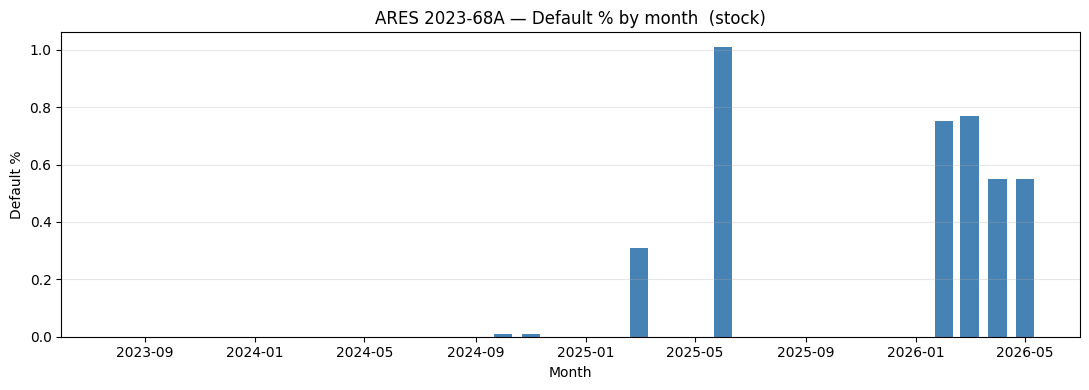

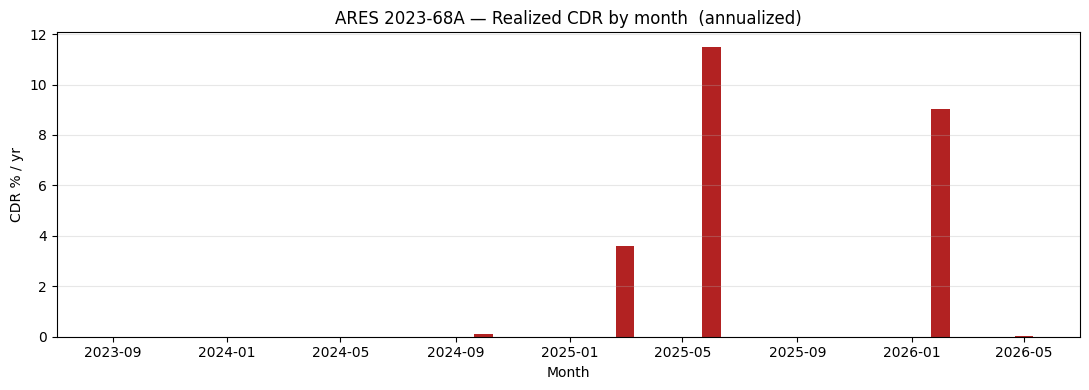

In [3]:
import matplotlib.pyplot as plt

file['date'] = pd.to_datetime(file['date'])

# Graph 1 — Default % per month (stock: balance currently in default)
plt.figure(figsize=(11, 4))
plt.bar(file['date'], file['default_pct'], width=20, color='steelblue')
plt.title('ARES 2023-68A — Default % by month  (stock)')
plt.ylabel('Default %')
plt.xlabel('Month')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Graph 2 — Realized CDR per month (flow: 1-(1-MDR)^12, annualized, %)
plt.figure(figsize=(11, 4))
plt.bar(file['date'], file['cdr_pct'], width=20, color='firebrick')
plt.title('ARES 2023-68A — Realized CDR by month  (annualized)')
plt.ylabel('CDR % / yr')
plt.xlabel('Month')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [4]:
# Approximate realized CDR (flow) from the precomputed columns (USD thousands).
# new_default_flow_000s = newly-defaulted par each month (from the Default % stock).
episodes = file.loc[file['new_default_flow_000s'] > 0,
                    ['date', 'default_pct', 'new_default_flow_000s']]
print('Default episodes (new defaults):')
print(episodes.to_string(index=False))

total_new = file['new_default_flow_000s'].sum()    # 000s
avg_bal   = file['balance_000s'].mean()            # 000s
years     = (file['date'].max() - file['date'].min()).days / 365.25
cdr_est   = total_new / avg_bal / years * 100

print(f"\ncumulative new defaults : ${total_new/1000:,.1f}M")
print(f"avg pool balance        : ${avg_bal/1000:,.1f}M")
print(f"deal span               : {years:.1f} years")
print(f"approx deal-to-date CDR : {cdr_est:.2f}% / yr  (ESTIMATE)")
print("vs assumed 2 CDR -> realized default intensity is far lower.")

Default episodes (new defaults):
      date  default_pct  new_default_flow_000s
2024-10-01         0.01                50.4935
2024-11-01         0.01                 0.3167
2025-03-01         0.31              1563.6183
2025-06-01         1.01              5124.4471
2026-02-01         0.75              3800.9175
2026-03-01         0.77                 2.6669
2026-05-01         0.55                17.7100

cumulative new defaults : $10.6M
avg pool balance        : $506.6M
deal span               : 3.0 years
approx deal-to-date CDR : 0.69% / yr  (ESTIMATE)
vs assumed 2 CDR -> realized default intensity is far lower.
